#Importing Libraries



In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score
from sklearn.model_selection import cross_val_score

#Dataset

In [1]:
!wget --no-check-certificate https://drive.google.com/uc?id=1cutKJ9D8WsVqSIF5E6gbkNKd9aCcKcVe -O HrDataset.csv

--2026-04-18 13:23:37--  https://drive.google.com/uc?id=1cutKJ9D8WsVqSIF5E6gbkNKd9aCcKcVe
Resolving drive.google.com (drive.google.com)... 64.233.181.101, 64.233.181.138, 64.233.181.139, ...
Connecting to drive.google.com (drive.google.com)|64.233.181.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1cutKJ9D8WsVqSIF5E6gbkNKd9aCcKcVe [following]
--2026-04-18 13:23:37--  https://drive.usercontent.google.com/download?id=1cutKJ9D8WsVqSIF5E6gbkNKd9aCcKcVe
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.184.132, 2607:f8b0:4001:c66::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.184.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 566785 (554K) [application/octet-stream]
Saving to: ‘HrDataset.csv’

HrDataset.csv       100%[===================>] 553.50K  --.-KB/s    in 0.006s  

2026-04-18 13:23:39 (95.0 MB/s)

#Load Dataset

In [3]:
df=pd.read_csv('HrDataset.csv')

#Basic Data Understanding

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [5]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [6]:
df.isna().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
Department,0
salary,0


#Exploratory Data Analysis (EDA)

In [7]:
df[(df['satisfaction_level']<df['satisfaction_level'].mean()) & (df['average_montly_hours']>df['average_montly_hours'].mean())]['left'].value_counts()

,count
left,
0,1909
1,1006


In [9]:
pd.crosstab(index=df['left'],
            columns=df['satisfaction_level'],
            rownames=['left'],
            colnames=['satisfaction'])

satisfaction,0.09,0.10,0.11,0.12,0.13,0.14,0.15,0.16,0.17,0.18,...,0.91,0.92,0.93,0.94,0.95,0.96,0.97,0.98,0.99,1.00
left,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,26,51,63,73,78,67,63,...,181,178,169,167,181,203,176,183,172,111
1,195,358,335,4,3,10,3,1,5,0,...,43,20,0,0,0,0,0,0,0,0


###Burnout Analysis

In [8]:
burnout_group = df[
    (df['satisfaction_level'] < df['satisfaction_level'].mean()) &
    (df['average_montly_hours'] > df['average_montly_hours'].mean())
]

burnout_group['left'].mean()

np.float64(0.3451114922813036)

### Relationship Analysis

In [10]:
left_emp=df[df['left']==1]
left_emp[['satisfaction_level','average_montly_hours']].corr()

,satisfaction_level,average_montly_hours
satisfaction_level,1.000000,-0.084117
average_montly_hours,-0.084117,1.000000


In [11]:
left_emp.groupby('satisfaction_level')['average_montly_hours'].mean()

,average_montly_hours
satisfaction_level,
0.09,275.692308
0.10,275.703911
0.11,278.000000
0.12,242.500000
0.13,152.000000
...,...
0.88,240.400000
0.89,236.446429
0.90,245.557692


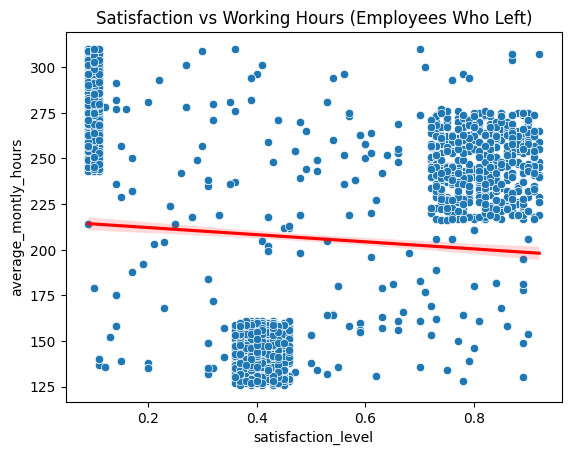

In [12]:
sns.scatterplot(data=left_emp, x='satisfaction_level', y='average_montly_hours')
sns.regplot(data=left_emp, x='satisfaction_level',y='average_montly_hours',scatter=False, color='red')
plt.title('Satisfaction vs Working Hours (Employees Who Left)')
plt.show()

###Group Analysis

In [13]:
df.groupby('Department')['left'].value_counts()

Department   left
IT           0        954
             1        273
RandD        0        666
             1        121
accounting   0        563
             1        204
hr           0        524
             1        215
management   0        539
             1         91
marketing    0        655
             1        203
product_mng  0        704
             1        198
sales        0       3126
             1       1014
support      0       1674
             1        555
technical    0       2023
             1        697
Name: count, dtype: int64

In [14]:
df.groupby(by=['Department','salary'])['left'].value_counts()

Department   salary  left
IT           high    0         79
                     1          4
             low     0        437
                     1        172
             medium  0        438
                     1         97
RandD        high    0         47
                     1          4
             low     0        309
                     1         55
             medium  0        310
                     1         62
accounting   high    0         69
                     1          5
             low     0        259
                     1         99
             medium  0        235
                     1        100
hr           high    0         39
                     1          6
             low     0        243
                     1         92
             medium  0        242
                     1        117
management   high    0        224
                     1          1
             low     0        121
                     1         59
             medium  0        194
                     1         31
marketing    high    0         71
                     1          9
             low     0        276
                     1        126
             medium  0        308
                     1         68
product_mng  high    0         62
                     1          6
             low     0        346
                     1        105
             medium  0        296
                     1         87
sales        high    0        255
                     1         14
             low     0       1402
                     1        697
             medium  0       1469
                     1        303
support      high    0        133
                     1          8
             low     0        757
                     1        389
             medium  0        784
                     1        158
technical    high    0        176
                     1         25
             low     0        994
                     1        378
             medium  0        853
                     1        294
Name: count, dtype: int64

In [16]:
df[df['time_spend_company'] <= 5].groupby(by=['salary', 'left']).size()

salary  left
high    0        980
        1         82
low     0       4794
        1       2037
medium  0       4581
        1       1243
dtype: int64

# Data Preprocessing

###Encode Salary (Ordinal)

In [27]:
fn={'low':0,'medium':1,'high':2}
df['salary']=df['salary'].map(fn)

###One-Hot Encode Department

In [29]:
df=pd.get_dummies(df,columns=['Department'],drop_first=True) #drop_first=True -->avoids dummy variable trap

#Feature & Target Split

In [31]:
features=df.columns.drop('left')
y=df['left']

In [32]:
X=df[features]

#Train-Test Split

In [43]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=100)

#Model Training

In [44]:
model=RandomForestClassifier(n_estimators=50)
model.fit(X_train,y_train)

RandomForestClassifier(n_estimators=50)

#Predictions

In [60]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

#Model Evaluation

###Classification Metrics

In [62]:
print("classification_report\n",classification_report(y_test,y_pred))

classification_report
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      2250
           1       0.99      0.98      0.99       750

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



In [61]:
print("Confusion matrix\n",confusion_matrix(y_test,y_pred))

classification_report
 [[2246    4]
 [  14  736]]


###ROC-AUC

In [52]:
print('roc-auc score:',roc_auc_score(y_test,y_pred)) #how well your model separates classes (left vs not left)

roc-auc score: 0.9897777777777776


###ROC-AUC Curve

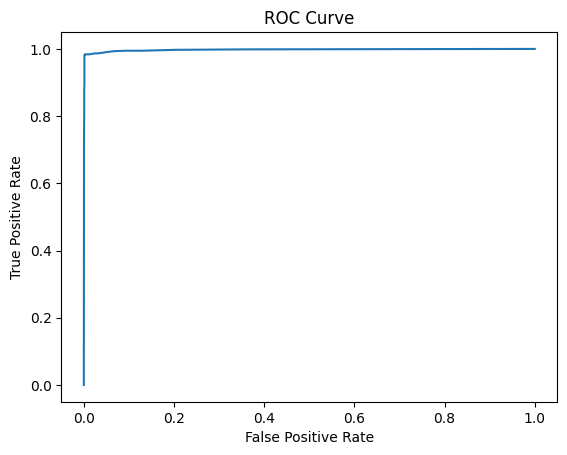

In [54]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

#Threshold Tuning

In [63]:
for t in [0.5,0.4,0.3]:
  y_pred_tuned=(y_pred_proba>t).astype(int)
  print(f'Threshold: {t}')
  print(confusion_matrix(y_test,y_pred_tuned))

Threshold: 0.5
[[2246    4]
 [  14  736]]
Threshold: 0.4
[[2246    4]
 [  13  737]]
Threshold: 0.3
[[2241    9]
 [  12  738]]


#Feature Importance

In [46]:
feature_imp=pd.DataFrame({'fetures':X.columns,'importance':model.feature_importances_})

In [47]:
feature_imp.sort_values(by='importance',ascending=False)

,fetures,importance
0,satisfaction_level,0.317543
4,time_spend_company,0.191145
2,number_project,0.182586
3,average_montly_hours,0.150301
1,last_evaluation,0.118483
7,salary,0.013104
5,Work_accident,0.007630
14,Department_sales,0.003483
16,Department_technical,0.003318
15,Department_support,0.002415


#Cross Validation

In [64]:
scores=cross_val_score(model,X,y,cv=5,scoring='roc_auc')
print(scores)
print("mean of scores:",scores.mean())

[0.99973497 0.98155347 0.98560198 0.99947862 0.99953294]
mean of scores: 0.9931803969214028
